# CSI4142 Assignment 4

**Group:** 80 

**Student 1:** Omar Khattab, S#300202727

**Student 2:** Iyad Ibrahim, S#7469152  

**Work split for Assignment 4:**
- Omar: **Dataset choice, notebook structure, dataset description, data preparation and EDA, Study 1 (Similarity Measures), and Study 2 (Clustering Algorithms)**
- Iyad: **Study 3 (Content-Based Recommendation System), Study 4 (Collaborative Filtering Recommendation System), references, and final reproducibility / cleanup pass**
- Shared: **final review, final integration, and demo preparation**



## 1) Dataset
- **Name:** The Movies Dataset
- **Author:** Rounak Banik
- **Purpose:** Contains movie metadata and individual user ratings for recommendation-system analysis.
- **Kaggle link:** https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset
- **Public metadata CSV used in this notebook:** https://raw.githubusercontent.com/softhints/Pandas-Exercises-Projects/main/data/movies_metadata.csv
- **Public ratings CSV used in this notebook:** https://raw.githubusercontent.com/aymanibrahim/movies_dataset/main/data/ratings_small.csv

**Why this dataset fits the assignment**
- `movies_metadata.csv` provides the metadata used in Studies 1 to 3.
- `ratings_small.csv` provides the individual user ratings used in Study 4.
- The shared movie identifier allows the metadata and ratings files to be connected within one notebook.


In [2]:

import ast
import warnings

import matplotlib
# Keep plots inside the notebook output cells.
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
plt.ioff()
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
# Public links are used so the notebook can run without local files.
MOVIES_METADATA_URL = "https://raw.githubusercontent.com/softhints/Pandas-Exercises-Projects/main/data/movies_metadata.csv"
RATINGS_SMALL_URL = "https://raw.githubusercontent.com/aymanibrahim/movies_dataset/main/data/ratings_small.csv"


In [3]:

metadata_columns = [
    "id", "title", "genres", "budget", "revenue", "runtime", "popularity",
    "release_date", "original_language", "overview"
]

movies_raw = pd.read_csv(MOVIES_METADATA_URL, low_memory=False, usecols=metadata_columns)
ratings_raw = pd.read_csv(RATINGS_SMALL_URL)

print("movies_raw shape:", movies_raw.shape)
print("ratings_raw shape:", ratings_raw.shape)
display(Markdown("### Metadata preview"))
display(movies_raw.head(3))
display(Markdown("### Ratings preview"))
display(ratings_raw.head(3))


movies_raw shape: (45466, 10)
ratings_raw shape: (100004, 4)


### Metadata preview

,budget,genres,id,original_language,overview,popularity,release_date,revenue,runtime,title
0,30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",862,en,"Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,373554033.0,81.0,Toy Story
1,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",8844,en,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,262797249.0,104.0,Jumanji
2,0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",15602,en,A family wedding reignites the ancient feud be...,11.7129,1995-12-22,0.0,101.0,Grumpier Old Men


### Ratings preview

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182


**Observation:** The notebook loads both dataset files successfully from public URLs and now shows a preview of each one. The metadata table has shape **45,466 x 10** and the ratings table has shape **100,004 x 4**, which makes the two-file dataset structure clear for the later studies.


In [4]:

def parse_genres(value):
    # The raw file stores genres as a string that looks like a Python list of dictionaries.
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(value)
        return [item.get("name") for item in parsed if isinstance(item, dict) and item.get("name")]
    except (ValueError, SyntaxError, TypeError):
        return []

# Work on a copy so the original raw table stays unchanged.
movies = movies_raw.copy()
# Create a numeric movie key so it can later match the ratings file.
movies["movieId"] = pd.to_numeric(movies["id"], errors="coerce")
# Convert the main numeric fields once here so later studies can reuse them.
for col in ["budget", "revenue", "runtime", "popularity"]:
    movies[col] = pd.to_numeric(movies[col], errors="coerce")

# Turn the raw release date into a datetime and keep the year as a simpler feature.
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year
# Parse genres into a usable list and a readable text version.
movies["genres_list"] = movies["genres"].apply(parse_genres)
movies["genres_text"] = movies["genres_list"].apply(lambda values: ", ".join(values) if values else "Unknown")
# Normalize titles so matching requests is more reliable.
movies["title_clean"] = movies["title"].fillna("").str.strip()

# Keep only rows that can be matched and displayed properly in the recommendation steps.
movies_clean = movies.dropna(subset=["movieId", "title_clean"]).copy()
movies_clean = movies_clean[movies_clean["title_clean"].ne("")]
movies_clean["movieId"] = movies_clean["movieId"].astype(int)

print("movies_clean shape:", movies_clean.shape)
movies_clean[["movieId", "title", "genres_text", "budget", "runtime", "popularity", "release_year"]].head()


movies_clean shape: (45460, 15)


,movieId,title,genres_text,budget,runtime,popularity,release_year
0,862,Toy Story,"Animation, Comedy, Family",30000000.0,81.0,21.946943,1995.0
1,8844,Jumanji,"Adventure, Fantasy, Family",65000000.0,104.0,17.015539,1995.0
2,15602,Grumpier Old Men,"Romance, Comedy",0.0,101.0,11.712900,1995.0
3,31357,Waiting to Exhale,"Comedy, Drama, Romance",16000000.0,127.0,3.859495,1995.0
4,11862,Father of the Bride Part II,Comedy,0.0,106.0,8.387519,1995.0


**Observation:** After the initial cleaning step, the working metadata table still contains **45,460** movies. This means only a very small number of rows were removed, so the cleaning is light and preserves almost the full dataset for the studies.



## Dataset Description

This notebook uses **The Movies Dataset**. The metadata file contains descriptive movie attributes such as title, genre, budget, runtime, popularity, release date, language, and overview. The ratings file contains individual user ratings that will later support collaborative filtering.


In [5]:

feature_catalog = pd.DataFrame([
    ["id", "movie identifier from the metadata file", "identifier"],
    ["title", "movie title", "text"],
    ["genres", "list of movie genres", "categorical / multi-label"],
    ["budget", "production budget", "numerical"],
    ["revenue", "box office revenue", "numerical"],
    ["runtime", "movie duration in minutes", "numerical"],
    ["popularity", "popularity score in the dataset", "numerical"],
    ["release_date", "movie release date", "date"],
    ["original_language", "original language code", "categorical"],
    ["overview", "short text description", "text"],
    ["userId", "user identifier from ratings_small.csv", "identifier"],
    ["movieId", "movie identifier used in the ratings file", "identifier"],
    ["rating", "user rating given to a movie", "numerical"],
    ["timestamp", "time when the rating was recorded", "numerical / timestamp"],
], columns=["Feature", "Description", "Type"])

print("Metadata rows / columns:", movies_raw.shape)
print("Ratings rows / columns:", ratings_raw.shape)
display(feature_catalog)


Metadata rows / columns: (45466, 10)
Ratings rows / columns: (100004, 4)


,Feature,Description,Type
0,id,movie identifier from the metadata file,identifier
1,title,movie title,text
2,genres,list of movie genres,categorical / multi-label
3,budget,production budget,numerical
4,revenue,box office revenue,numerical
5,runtime,movie duration in minutes,numerical
6,popularity,popularity score in the dataset,numerical
7,release_date,movie release date,date
8,original_language,original language code,categorical
9,overview,short text description,text


**Observation:** The feature table includes both the movie metadata fields and the ratings fields (`userId`, `movieId`, `rating`, and `timestamp`). This shows that the dataset contains the linked metadata and user-rating information needed for the assignment, along with a mix of identifier, numerical, categorical, and text features.


In [6]:

overlap_movie_ids = len(set(movies_clean["movieId"]).intersection(set(ratings_raw["movieId"])))
print("Overlapping movie IDs between metadata and ratings:", overlap_movie_ids)
print("This overlap confirms that the metadata side (Studies 1-3) and the ratings side (Study 4) can be connected.")


Overlapping movie IDs between metadata and ratings: 2830
This overlap confirms that the metadata side (Studies 1-3) and the ratings side (Study 4) can be connected.


**Observation:** There are **2,830 overlapping movie IDs** between the metadata and ratings files. This confirms that the chosen movie dataset is internally consistent enough to support both the metadata-based studies and the later collaborative filtering study.



## 2. Data Preparation and EDA

The assignment leaves this section open, so we focused on cleaning the fields needed for the first two studies and producing a few clear exploratory checks.


In [7]:

# Quick missing-value check for the columns used in Omar's sections.
selected_columns = ["title", "genres", "budget", "revenue", "runtime", "popularity", "release_date", "original_language"]
missing_summary = (
    movies_clean[selected_columns]
    .isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(movies_clean) * 100).round(2)
missing_summary


,missing_count,missing_pct
title,0,0.00
genres,0,0.00
budget,0,0.00
revenue,0,0.00
runtime,257,0.57
popularity,0,0.00
release_date,84,0.18
original_language,11,0.02


**Observation:** Missing values are low in the fields used so far. The largest gap is in `runtime` at only **257 rows (0.57%)**, while `release_date` and `original_language` have even smaller missing rates. This means the selected attributes are usable without heavy imputation for Omar's portion of the notebook.


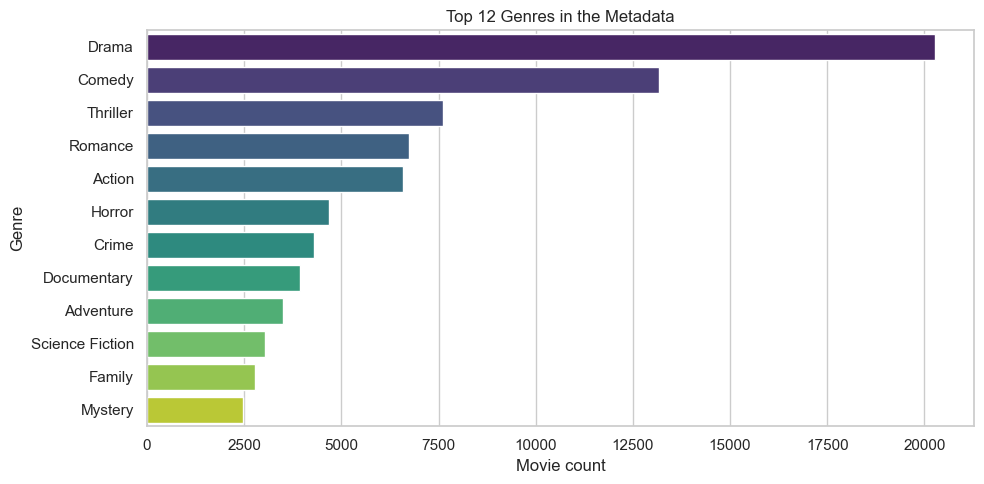

In [8]:

# Explode the genre lists so each genre can be counted separately.
all_genres = movies_clean.explode("genres_list")
all_genres = all_genres[all_genres["genres_list"].notna() & all_genres["genres_list"].ne("")]

genre_counts = all_genres["genres_list"].value_counts().head(12)
plt.figure(figsize=(10, 5))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.title("Top 12 Genres in the Metadata")
plt.xlabel("Movie count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


**Observation:** The genre count plot shows that `Drama` and `Comedy` are the most common genres in the dataset. This is useful for Study 1 because genre-based similarity has enough coverage to return many reasonable candidate movies.


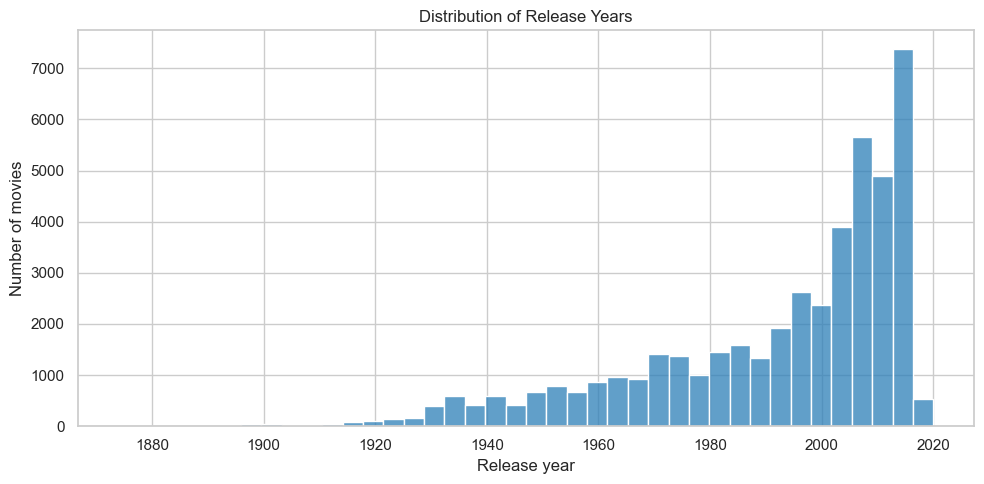

In [9]:

release_years = movies_clean["release_year"].dropna()
plt.figure(figsize=(10, 5))
sns.histplot(release_years, bins=40, color="#2c7fb8")
plt.title("Distribution of Release Years")
plt.xlabel("Release year")
plt.ylabel("Number of movies")
plt.tight_layout()
plt.show()


**Observation:** The release-year plot shows that the dataset spans a long time period, but most of the movies are concentrated in the more recent decades. The counts rise noticeably from the second half of the 20th century onward, with the highest concentration appearing in the 2000s and 2010s, so the dataset is broad but still mostly modern overall.


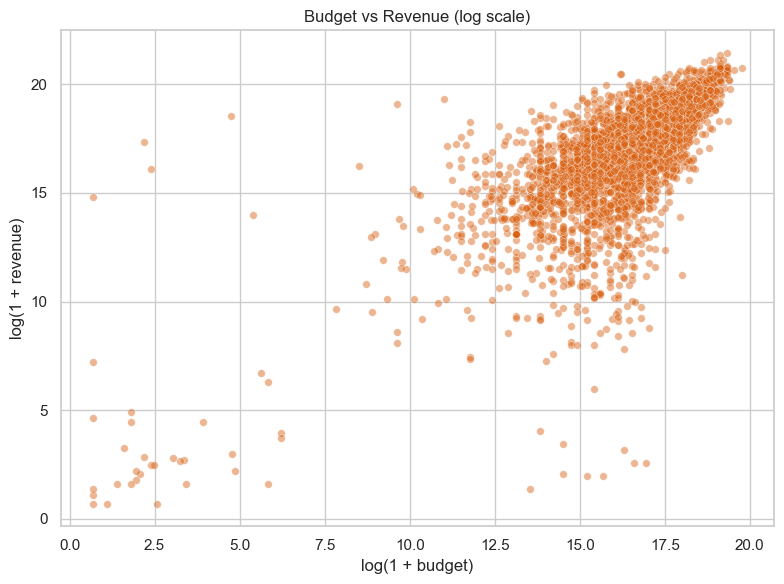

In [10]:

# Remove missing / zero values and sample for a cleaner scatter plot.
eda_scatter = movies_clean[["budget", "revenue"]].dropna().copy()
eda_scatter = eda_scatter[(eda_scatter["budget"] > 0) & (eda_scatter["revenue"] > 0)]
eda_scatter = eda_scatter.sample(min(len(eda_scatter), 4000), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=eda_scatter,
    x=np.log1p(eda_scatter["budget"]),
    y=np.log1p(eda_scatter["revenue"]),
    alpha=0.45,
    s=30,
    color="#d95f0e"
)
plt.title("Budget vs Revenue (log scale)")
plt.xlabel("log(1 + budget)")
plt.ylabel("log(1 + revenue)")
plt.tight_layout()
plt.show()


**Observation:** The budget-versus-revenue scatter plot shows a positive relationship rather than a random spread. Movies with larger budgets tend to have larger revenues as well, which makes these two attributes reasonable choices for similarity and clustering.


**Final EDA Observation:** Overall, the EDA suggests that the selected metadata is usable for the next studies. Missing values are limited, the dataset has strong genre coverage, the time distribution is broad, and the numeric movie attributes show enough visible structure to support the similarity and clustering tasks.



### Preparation Notes

- The metadata `id` was converted into a numeric `movieId` when possible.
- Numeric fields such as budget, revenue, runtime, and popularity were coerced to numeric values.
- `genres` was parsed from its JSON-like string representation into a list of genre names.
- `release_date` was converted into a proper datetime and a `release_year` column was derived for later use.
- Rows missing a valid movie identifier or title were removed from the working metadata table.



## 3. Study 1: Similarity Measures

For this study we use five metadata attributes and five request styles:
- **Genres** with Jaccard similarity
- **Budget and Revenue** with Euclidean similarity
- **Runtime** with Manhattan similarity
- **Popularity** with Canberra similarity
- **Title** with edit-distance similarity

For all requests, the final ranking is based first on similarity and then on popularity.


In [11]:

def choose_reference_movie(title):
    # If a title appears more than once, keep the most popular / most recent match.
    matches = movies_clean[movies_clean["title_clean"].str.casefold() == title.casefold()].copy()
    if matches.empty:
        raise ValueError(f"Title not found: {title}")
    return matches.sort_values(["popularity", "release_year"], ascending=[False, False]).iloc[0]


def jaccard_similarity(left, right):
    left_set = set(left)
    right_set = set(right)
    if not left_set and not right_set:
        return 0.0
    return len(left_set & right_set) / len(left_set | right_set)


def euclidean_similarity(left_values, right_values, scales):
    # Normalize each dimension first so budget and revenue are on comparable scales.
    left_arr = np.asarray(left_values, dtype=float)
    right_arr = np.asarray(right_values, dtype=float)
    scale_arr = np.asarray(scales, dtype=float)

    if np.isnan(left_arr).any() or np.isnan(right_arr).any() or np.any(scale_arr == 0):
        return np.nan

    normalized_diff = (left_arr - right_arr) / scale_arr
    distance = np.sqrt(np.sum(normalized_diff ** 2))
    return 1 / (1 + distance)


def manhattan_similarity(x, y, scale):
    if pd.isna(x) or pd.isna(y) or scale == 0:
        return np.nan
    distance = abs(x - y) / scale
    return 1 / (1 + distance)


def canberra_similarity(x, y):
    if pd.isna(x) or pd.isna(y):
        return np.nan
    denom = abs(x) + abs(y)
    if denom == 0:
        return 1.0
    return 1 - abs(x - y) / denom


def edit_distance(a, b):
    a = a.casefold()
    b = b.casefold()
    dp = list(range(len(b) + 1))
    for i, char_a in enumerate(a, start=1):
        prev = dp[0]
        dp[0] = i
        for j, char_b in enumerate(b, start=1):
            current = dp[j]
            if char_a == char_b:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])
            prev = current
    return dp[-1]


def title_similarity(a, b):
    max_len = max(len(a), len(b))
    if max_len == 0:
        return 1.0
    return 1 - edit_distance(a, b) / max_len


budget_scale = movies_clean["budget"].dropna().max() - movies_clean["budget"].dropna().min()
revenue_scale = movies_clean["revenue"].dropna().max() - movies_clean["revenue"].dropna().min()
runtime_scale = movies_clean["runtime"].dropna().max() - movies_clean["runtime"].dropna().min()


def run_similarity_request(reference_title, attribute_name, similarity_builder):
    ref = choose_reference_movie(reference_title)
    working = movies_clean.copy()
    working = working[working["movieId"] != ref["movieId"]].copy()
    # Apply one similarity rule at a time, then sort by similarity and popularity.
    working["similarity"] = working.apply(lambda row: similarity_builder(ref, row), axis=1)
    working = working.dropna(subset=["similarity"])
    working = working.sort_values(["similarity", "popularity", "release_year"], ascending=[False, False, False])
    return ref, working.head(10)[["title", "genres_text", "budget", "revenue", "runtime", "popularity", "release_year", "similarity"]]


In [12]:

# Each request highlights one similarity measure from the study.
requests = [
    {
        "label": "Request 1: Show me movies of the same genre as Toy Story",
        "title": "Toy Story",
        "attribute": "genres",
        "builder": lambda ref, row: jaccard_similarity(ref["genres_list"], row["genres_list"]),
    },
    {
        "label": "Request 2: Show me movies with a similar budget and revenue profile to The Matrix",
        "title": "The Matrix",
        "attribute": "budget_and_revenue",
        "builder": lambda ref, row: euclidean_similarity(
            [ref["budget"], ref["revenue"]],
            [row["budget"], row["revenue"]],
            [budget_scale, revenue_scale],
        ),
    },
    {
        "label": "Request 3: Show me movies with a similar runtime to Apollo 13",
        "title": "Apollo 13",
        "attribute": "runtime",
        "builder": lambda ref, row: manhattan_similarity(ref["runtime"], row["runtime"], runtime_scale),
    },
    {
        "label": "Request 4: Show me movies with popularity similar to Titanic",
        "title": "Titanic",
        "attribute": "popularity",
        "builder": lambda ref, row: canberra_similarity(ref["popularity"], row["popularity"]),
    },
    {
        "label": "Request 5: Show me movies with a similar title to Fight Club",
        "title": "Fight Club",
        "attribute": "title",
        "builder": lambda ref, row: title_similarity(ref["title_clean"], row["title_clean"]),
    },
]

# Show the reference movie first, then the Top 10 matches.
for request in requests:
    ref_movie, top_matches = run_similarity_request(
        reference_title=request["title"],
        attribute_name=request["attribute"],
        similarity_builder=request["builder"],
    )
    display(Markdown(f"### {request['label']}"))
    display(pd.DataFrame([
        {
            "reference_title": ref_movie["title"],
            "genres": ref_movie["genres_text"],
            "budget": ref_movie["budget"],
            "revenue": ref_movie["revenue"],
            "runtime": ref_movie["runtime"],
            "popularity": ref_movie["popularity"],
            "release_year": ref_movie["release_year"],
        }
    ]))
    display(top_matches.reset_index(drop=True))


### Request 1: Show me movies of the same genre as Toy Story

,reference_title,genres,budget,revenue,runtime,popularity,release_year
0,Toy Story,"Animation, Comedy, Family",30000000.0,373554033.0,81.0,21.946943,1995.0


,title,genres_text,budget,revenue,runtime,popularity,release_year,similarity
0,The Emoji Movie,"Comedy, Family, Animation",50000000.0,6.691394e+07,86.0,33.694599,2017.0,1.0
1,"Monsters, Inc.","Animation, Comedy, Family",115000000.0,5.628163e+08,92.0,26.419962,2001.0,1.0
2,Despicable Me 2,"Animation, Comedy, Family",76000000.0,9.707619e+08,98.0,24.823550,2013.0,1.0
3,Chicken Little,"Animation, Family, Comedy",150000000.0,3.144327e+08,81.0,18.584609,2005.0,1.0
4,Toy Story 2,"Animation, Comedy, Family",90000000.0,4.973669e+08,92.0,17.547693,1999.0,1.0
5,Toy Story 3,"Animation, Family, Comedy",200000000.0,1.066970e+09,103.0,16.966470,2010.0,1.0
6,Cloudy with a Chance of Meatballs 2,"Animation, Family, Comedy",78000000.0,2.483846e+08,95.0,14.412061,2013.0,1.0
7,The Simpsons Movie,"Animation, Comedy, Family",75000000.0,5.270689e+08,87.0,14.302911,2007.0,1.0
8,Looney Tunes: Back in Action,"Animation, Comedy, Family",80000000.0,6.851484e+07,90.0,13.666488,2003.0,1.0
9,The Boss Baby,"Animation, Comedy, Family",125000000.0,4.988149e+08,97.0,13.392824,2017.0,1.0


### Request 2: Show me movies with a similar budget and revenue profile to The Matrix

,reference_title,genres,budget,revenue,runtime,popularity,release_year
0,The Matrix,"Action, Science Fiction",63000000.0,463517383.0,136.0,33.366332,1999.0


...

,reference_title,genres,budget,revenue,runtime,popularity,release_year
0,Titanic,"Drama, Romance, Thriller",200000000.0,1.845034e+09,194.0,26.88907,1997.0


,title,genres_text,budget,revenue,runtime,popularity,release_year,similarity
0,Ant-Man,"Science Fiction, Action, Adventure",130000000.0,5.193120e+08,117.0,26.882388,2015.0,0.999876
1,Pan's Labyrinth,"Fantasy, Drama, War",19000000.0,8.325823e+07,118.0,26.817754,2006.0,0.998672
2,Dark Skies,"Science Fiction, Thriller, Horror",3500000.0,2.517432e+07,97.0,26.972326,2013.0,0.998454
3,The Hunger Games: Mockingjay - Part 2,"Action, Adventure, Science Fiction",160000000.0,6.534283e+08,137.0,26.628178,2015.0,0.995125
4,Furious 7,Action,190000000.0,1.506249e+09,137.0,27.275687,2015.0,0.992862
5,"Monsters, Inc.","Animation, Comedy, Family",115000000.0,5.628163e+08,92.0,26.419962,2001.0,0.991200
6,Sex Tape,Comedy,40000000.0,1.260695e+08,97.0,27.470696,2014.0,0.989300
7,Assassin's Creed,"Action, Adventure, Science Fiction",125000000.0,2.406979e+08,115.0,27.541070,2016.0,0.988021
8,The Amazing Spider-Man 2,"Action, Adventure, Fantasy",200000000.0,7.057174e+08,142.0,26.236870,2014.0,0.987724
9,Spider-Man 3,"Fantasy, Action, Adventure",258000000.0,8.908716e+08,139.0,27.614265,2007.0,0.986694


### Request 5: Show me movies with a similar title to Fight Club

,reference_title,genres,budget,revenue,runtime,popularity,release_year
0,Fight Club,Drama,63000000.0,100853753.0,139.0,63.869599,1999.0


,title,genres_text,budget,revenue,runtime,popularity,release_year,similarity
0,Flight Crew,"Drama, Action",10000000.0,27305571.0,138.0,5.420460,2016.0,0.636364
1,Night Court,"Crime, Drama, Thriller",0.0,0.0,92.0,0.144281,1932.0,0.636364
2,The Club,Drama,0.0,52761.0,97.0,3.534068,2015.0,0.600000
3,The Club,Horror,0.0,0.0,94.0,0.573367,1994.0,0.600000
4,The Club,"Drama, Comedy",0.0,0.0,96.0,0.475739,1980.0,0.600000
5,Fightville,Documentary,0.0,0.0,85.0,0.439409,2011.0,0.600000
6,Female Fight Club,"Drama, Action",2000000.0,0.0,90.0,3.796019,2017.0,0.588235
7,Eight Below,"Adventure, Drama, Family",40000000.0,120455994.0,120.0,13.876881,2006.0,0.545455
8,Cougar Club,Comedy,0.0,0.0,93.0,5.556157,2007.0,0.545455
9,Flight 7500,"Thriller, Horror, Mystery",0.0,0.0,97.0,5.265969,2014.0,0.545455



**Observation (Study 1 Results):**

- **Genre similarity:** The `Toy Story` request returns many family-animation titles with a perfect Jaccard score of **1.0**, which shows that genre matching is very strong when the genre sets fully overlap.
- **Euclidean similarity:** The `The Matrix` request now compares a two-dimensional financial profile using both `budget` and `revenue`, which makes the Euclidean measure meaningfully different from the Manhattan runtime comparison.
- **Runtime similarity:** The `Apollo 13` request still produces many exact `140` minute matches, so the Top 10 results reach **1.0** similarity when the runtime is identical.
- **Popularity similarity:** The `Titanic` request returns movies with popularity scores very close to the reference title, which gives a softer ranking than exact genre or runtime matches.
- **Title similarity:** The `Fight Club` request remains the weakest semantically, which is expected because edit distance compares spelling rather than movie meaning.



### Study 1 Discussion

Across the five requests, the similarity measures behave differently depending on the type of attribute being compared. **Jaccard similarity** works well for `genres` because it directly compares overlap between sets, so it tends to return movies that are conceptually close to the reference title. The two numeric distance-based measures also behave differently: the **Euclidean** request compares a normalized two-feature `budget` and `revenue` profile, while the **Manhattan** request measures `runtime` difference on a single numeric attribute. **Canberra similarity** gives a softer comparison for `popularity` because it is sensitive to relative differences rather than exact matches. **Edit-distance similarity** is still useful for comparing `title` values, but it is the weakest indicator of actual movie similarity because spelling resemblance does not necessarily reflect similar content. For this study, the most meaningful results come from attribute choices that are directly related to movie characteristics, while title-based matching is better treated as a simple text comparison than a recommendation signal.



## 4. Study 2: Clustering Algorithms

To keep the visual inspection readable, we cluster on two pairs of numeric attributes from Study 1:
- **budget vs runtime**
- **runtime vs popularity**

For each pair, we test:
- KMeans with `k=3` and `k=5`
- DBSCAN with `(eps=0.12, min_samples=8)` and `(eps=0.18, min_samples=10)`


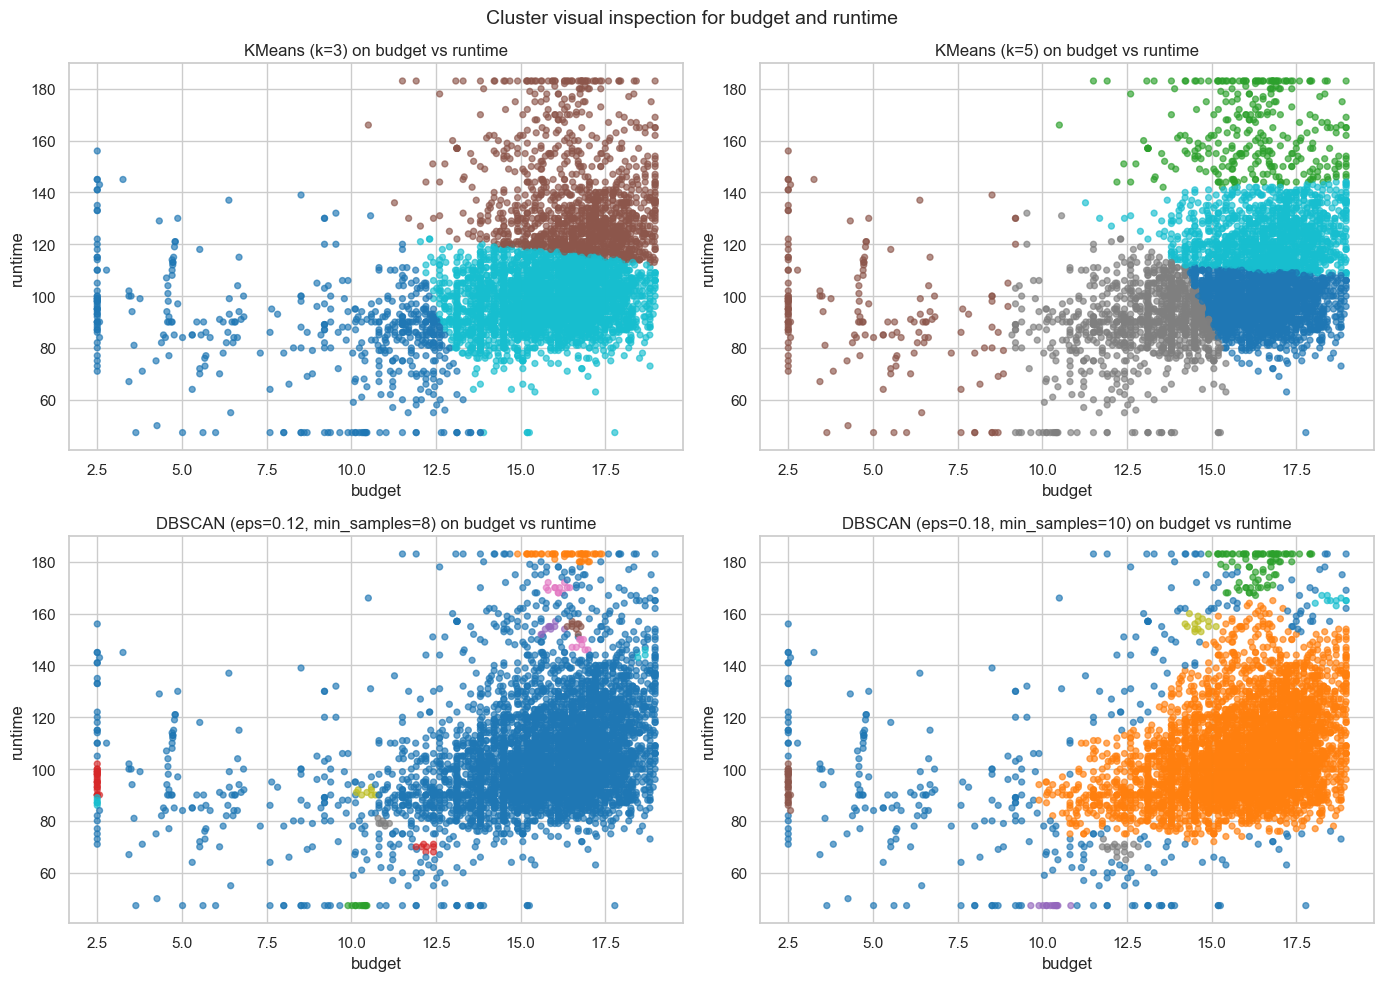

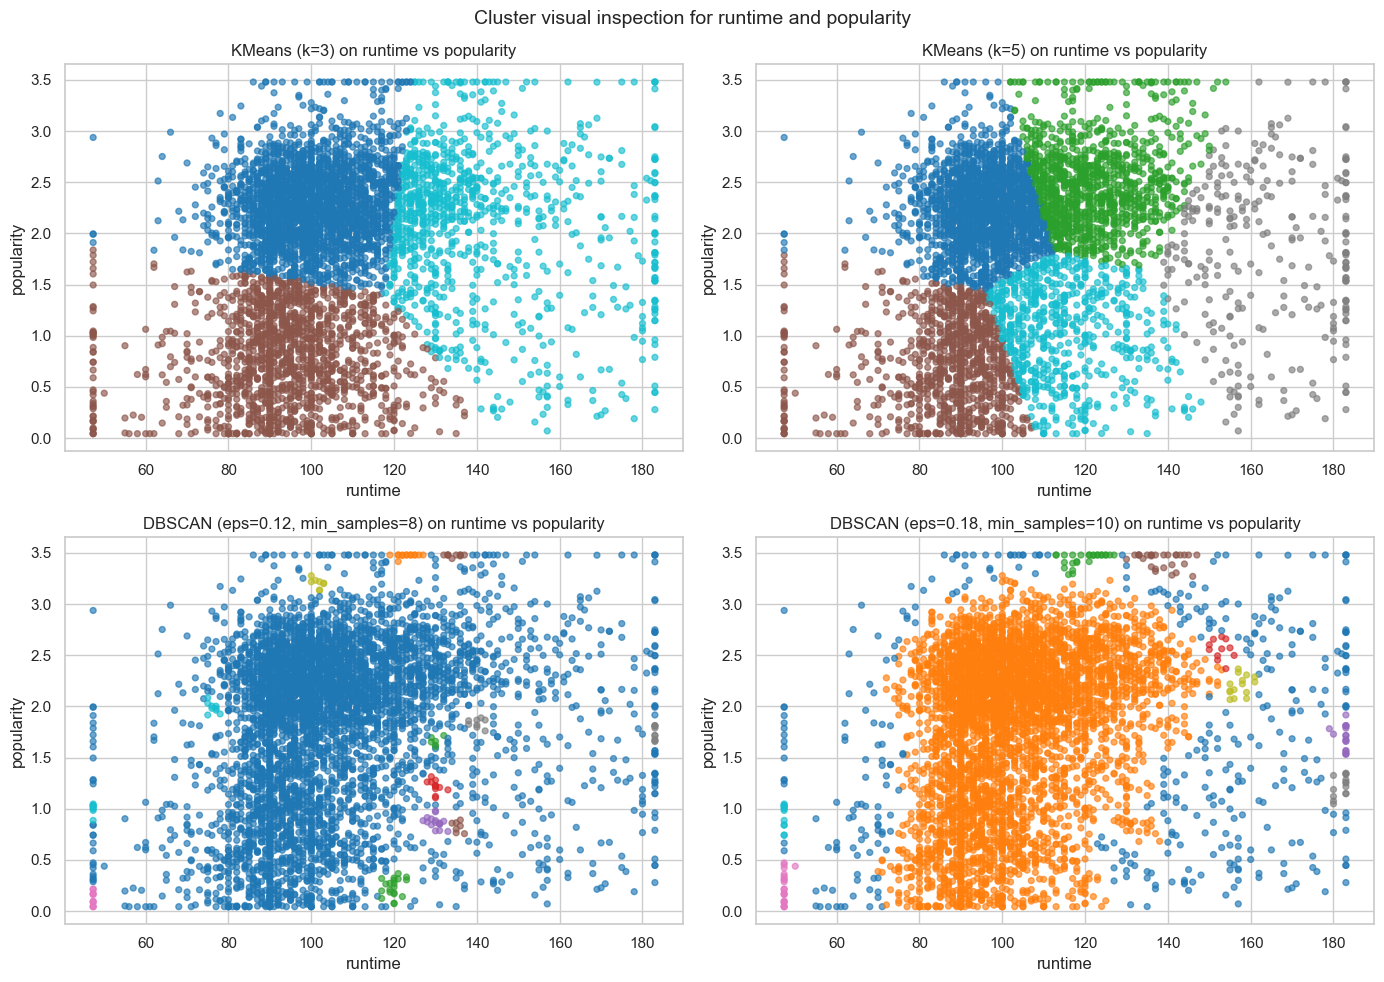

In [13]:

# Keep only valid numeric rows, trim extreme outliers, then sample for faster plotting.
cluster_base = movies_clean[["title", "budget", "runtime", "popularity"]].dropna().copy()
cluster_base = cluster_base[(cluster_base["budget"] > 0) & (cluster_base["runtime"] > 0) & (cluster_base["popularity"] > 0)]
for col in ["budget", "runtime", "popularity"]:
    low, high = cluster_base[col].quantile([0.01, 0.99])
    cluster_base[col] = cluster_base[col].clip(lower=low, upper=high)
cluster_base = cluster_base.sample(min(len(cluster_base), 5000), random_state=RANDOM_STATE)

combos = [
    ("budget", "runtime"),
    ("runtime", "popularity"),
]


def prepare_features(frame, x_col, y_col):
    prepared = frame[[x_col, y_col]].copy()
    # Log scaling helps compress very large budget / popularity values before clustering.
    if x_col in {"budget", "revenue", "popularity"}:
        prepared[x_col] = np.log1p(prepared[x_col])
    if y_col in {"budget", "revenue", "popularity"}:
        prepared[y_col] = np.log1p(prepared[y_col])
    scaled = StandardScaler().fit_transform(prepared)
    return prepared, scaled


def plot_cluster_grid(x_col, y_col):
    prepared, scaled = prepare_features(cluster_base, x_col, y_col)
    # Run the required parameter variations side by side for visual comparison.
    models = [
        (f"KMeans (k=3) on {x_col} vs {y_col}", KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE).fit_predict(scaled)),
        (f"KMeans (k=5) on {x_col} vs {y_col}", KMeans(n_clusters=5, n_init=20, random_state=RANDOM_STATE).fit_predict(scaled)),
        (f"DBSCAN (eps=0.12, min_samples=8) on {x_col} vs {y_col}", DBSCAN(eps=0.12, min_samples=8).fit_predict(scaled)),
        (f"DBSCAN (eps=0.18, min_samples=10) on {x_col} vs {y_col}", DBSCAN(eps=0.18, min_samples=10).fit_predict(scaled)),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (title, labels) in zip(axes.flatten(), models):
        scatter = ax.scatter(prepared[x_col], prepared[y_col], c=labels, cmap="tab10", alpha=0.65, s=18)
        ax.set_title(title)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
    fig.suptitle(f"Cluster visual inspection for {x_col} and {y_col}", fontsize=14)
    plt.tight_layout()
    plt.show()


for x_col, y_col in combos:
    plot_cluster_grid(x_col, y_col)


**Observation:** In the `budget vs runtime` plots, KMeans separates the movies into broad groups more clearly, especially when moving from `k=3` to `k=5`. DBSCAN does identify a main dense region and some smaller side groups, but many points are either absorbed into one dominant cluster or marked as noise.


**Observation:** In the `runtime vs popularity` plots, KMeans again gives cleaner partitions that are easier to compare visually. DBSCAN is more sensitive to the parameter choice here, and the plots suggest that popularity creates a dense central mass with several small edge groups rather than evenly separated clusters.


In [14]:

def cluster_count_summary(x_col, y_col):
    prepared, scaled = prepare_features(cluster_base, x_col, y_col)
    # This summary makes it easier to compare how many clusters and noise points each model produces.
    summaries = []
    model_specs = [
        ("KMeans", "k=3", KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE).fit_predict(scaled)),
        ("KMeans", "k=5", KMeans(n_clusters=5, n_init=20, random_state=RANDOM_STATE).fit_predict(scaled)),
        ("DBSCAN", "eps=0.12, min_samples=8", DBSCAN(eps=0.12, min_samples=8).fit_predict(scaled)),
        ("DBSCAN", "eps=0.18, min_samples=10", DBSCAN(eps=0.18, min_samples=10).fit_predict(scaled)),
    ]
    for algo, params, labels in model_specs:
        unique_labels, counts = np.unique(labels, return_counts=True)
        summaries.append({
            "attributes": f"{x_col} vs {y_col}",
            "algorithm": algo,
            "parameters": params,
            "clusters_excluding_noise": int(sum(label != -1 for label in unique_labels)),
            "noise_points": int(counts[unique_labels == -1][0]) if -1 in unique_labels else 0,
        })
    return pd.DataFrame(summaries)

summary_tables = [cluster_count_summary(x_col, y_col) for x_col, y_col in combos]
display(pd.concat(summary_tables, ignore_index=True))


,attributes,algorithm,parameters,clusters_excluding_noise,noise_points
0,budget vs runtime,KMeans,k=3,3,0
1,budget vs runtime,KMeans,k=5,5,0
2,budget vs runtime,DBSCAN,"eps=0.12, min_samples=8",13,570
3,budget vs runtime,DBSCAN,"eps=0.18, min_samples=10",7,346
4,runtime vs popularity,KMeans,k=3,3,0
5,runtime vs popularity,KMeans,k=5,5,0
6,runtime vs popularity,DBSCAN,"eps=0.12, min_samples=8",14,610
7,runtime vs popularity,DBSCAN,"eps=0.18, min_samples=10",9,393


**Observation:** The clustering summary supports the visual inspection. KMeans always creates the requested number of clusters, while DBSCAN finds more local groups but also labels many points as noise, from about **346** to **610** depending on the setting. For these two feature pairs, KMeans looks more stable, while DBSCAN is more useful for spotting dense pockets and outliers.



### Study 2 Discussion

Across both selected attribute pairs, **KMeans** produces cleaner and more stable groupings for visual interpretation because it consistently partitions the data into a fixed number of clusters. **DBSCAN** is still useful because it highlights dense regions and separates noise points, but its results change more noticeably when `eps` and `min_samples` are adjusted. In our plots, DBSCAN often forms one dominant dense cluster together with smaller side groups or noise, which makes the structure less straightforward to compare than the KMeans output. For this study, KMeans fits these 2D views better when the goal is to obtain clear and interpretable clusters, while DBSCAN is more informative when the goal is to identify outliers and local density patterns. This conclusion is based on the chosen feature pairs and visual inspection rather than a formal clustering quality metric.



## 5. Study 3: Content-Based Recommendation System

In this study, we define 2 metadata-based heuristics and apply both of them to the same 3 reference movies. This makes it easier to compare how the heuristics behave on the same recommendation requests.


In [15]:
# Study 3: Content-Based Recommendation System
# Two heuristics:
# - heuristic_a: genre overlap + recency (year closeness)
# - heuristic_b: numeric profile cosine (log budget/revenue + runtime + popularity)

from numpy.linalg import norm

movies_profile = movies_clean.copy()
movies_profile = movies_profile.dropna(subset=["genres_list", "release_year", "runtime", "popularity"])

# Precompute numeric vectors for heuristic B
movies_profile = movies_profile.assign(
    budget_log=np.log1p(movies_profile["budget"].fillna(0)),
    revenue_log=np.log1p(movies_profile["revenue"].fillna(0)),
)

numeric_cols = ["budget_log", "revenue_log", "runtime", "popularity"]


def genre_recency_similarity(ref, row):
    # Jaccard on genres
    j = jaccard_similarity(ref["genres_list"], row["genres_list"])
    # Year closeness: 1 - normalized difference over 30-year window
    year_diff = abs(ref["release_year"] - row["release_year"])
    recency = max(0.0, 1 - year_diff / 30)
    return 0.6 * j + 0.4 * recency


def numeric_cosine_similarity(ref_vec, row_vec):
    if np.any(np.isnan(ref_vec)) or np.any(np.isnan(row_vec)):
        return np.nan
    denom = norm(ref_vec) * norm(row_vec)
    if denom == 0:
        return np.nan
    return float(np.dot(ref_vec, row_vec) / denom)


def run_content_request(reference_title, sim_func, top_n=10):
    ref = choose_reference_movie(reference_title)
    ref_row = movies_profile[movies_profile["movieId"] == ref["movieId"]].iloc[0]
    candidates = movies_profile[movies_profile["movieId"] != ref["movieId"]].copy()

    if sim_func == "heuristic_a":
        candidates["similarity"] = candidates.apply(lambda row: genre_recency_similarity(ref_row, row), axis=1)
    else:
        ref_vec = ref_row[numeric_cols].to_numpy(dtype=float)
        candidates["similarity"] = candidates.apply(
            lambda row: numeric_cosine_similarity(ref_vec, row[numeric_cols].to_numpy(dtype=float)), axis=1
        )

    candidates = candidates.dropna(subset=["similarity"])
    ranked = candidates.sort_values(["similarity", "popularity", "release_year"], ascending=[False, False, False]).head(top_n)
    display(pd.DataFrame([
        {
            "reference_title": ref_row["title"],
            "genres": ref_row["genres_text"],
            "release_year": ref_row["release_year"],
            "runtime": ref_row["runtime"],
            "popularity": ref_row["popularity"],
        }
    ]))
    return ranked[["title", "genres_text", "release_year", "runtime", "popularity", "similarity"]].reset_index(drop=True)


# Run the same 3 requests under both heuristics so the results can be compared directly.
request_titles = ["Toy Story", "Apollo 13", "Fight Club"]
heuristics = [
    ("Heuristic A (genre + recency)", "heuristic_a"),
    ("Heuristic B (numeric cosine)", "heuristic_b"),
]

for ref_title in request_titles:
    for label, heuristic in heuristics:
        display(Markdown(f"### {label} — {ref_title}"))
        results = run_content_request(ref_title, heuristic, top_n=10)
        display(results)


### Heuristic A (genre + recency) — Toy Story

,reference_title,genres,release_year,runtime,popularity
0,Toy Story,"Animation, Comedy, Family",1995.0,81.0,21.946943


,title,genres_text,release_year,runtime,popularity,similarity
0,A Close Shave,"Family, Animation, Comedy",1995.0,30.0,6.796858,1.000000
1,A Flintstones Christmas Carol,"Animation, Comedy, Family",1994.0,70.0,0.872875,0.986667
2,Santa Claus and the Magic Drum,"Comedy, Animation, Family",1996.0,51.0,0.331975,0.986667
3,The Wrong Trousers,"Animation, Comedy, Family",1993.0,30.0,7.771233,0.973333
4,Meet the Deedles,"Animation, Comedy, Family",1998.0,93.0,7.336354,0.960000
5,Bébé's Kids,"Animation, Comedy, Family",1992.0,72.0,6.997911,0.960000
6,An All Dogs Christmas Carol,"Animation, Family, Comedy",1998.0,73.0,4.602352,0.960000
7,Toy Story 2,"Animation, Comedy, Family",1999.0,92.0,17.547693,0.946667
8,Mickey's Once Upon a Christmas,"Animation, Family, Comedy",1999.0,66.0,6.577491,0.946667
9,Bartok the Magnificent,"Animation, Comedy, Family",1999.0,67.0,4.284230,0.946667


### Heuristic B (numeric cosine) — Toy Story

,reference_title,genres,release_year,runtime,popularity
0,Toy Story,"Animation, Comedy, Family",1995.0,81.0,21.946943


...

,reference_title,genres,release_year,runtime,popularity
0,Fight Club,Drama,1999.0,139.0,63.869599


,title,genres_text,release_year,runtime,popularity,similarity
0,American Beauty,Drama,1999.0,122.0,20.726578,1.0
1,The Straight Story,Drama,1999.0,112.0,14.580995,1.0
2,Any Given Sunday,Drama,1999.0,163.0,10.571434,1.0
3,The Cider House Rules,Drama,1999.0,126.0,9.526781,1.0
4,Magnolia,Drama,1999.0,188.0,9.091636,1.0
5,Bringing Out the Dead,Drama,1999.0,121.0,8.825864,1.0
6,"Girl, Interrupted",Drama,1999.0,127.0,8.285062,1.0
7,Agnes Browne,Drama,1999.0,92.0,6.485631,1.0
8,Cradle Will Rock,Drama,1999.0,132.0,6.481649,1.0
9,The End of the Affair,Drama,1999.0,102.0,6.200344,1.0


### Heuristic B (numeric cosine) — Fight Club

,reference_title,genres,release_year,runtime,popularity
0,Fight Club,Drama,1999.0,139.0,63.869599


,title,genres_text,release_year,runtime,popularity,similarity
0,Guardians of the Galaxy,"Action, Science Fiction, Adventure",2014.0,121.0,53.291601,0.999016
1,Logan,"Action, Drama, Science Fiction",2017.0,137.0,54.581997,0.998552
2,John Wick: Chapter 2,"Thriller, Action, Crime",2017.0,122.0,49.247505,0.998552
3,Before I Fall,"Mystery, Drama, Thriller",2017.0,98.0,38.995136,0.997820
4,The Legend of Tarzan,"Action, Adventure",2016.0,109.0,45.382980,0.997502
5,The Shawshank Redemption,"Drama, Crime",1994.0,142.0,51.645403,0.996704
6,Doctor Strange,"Action, Adventure, Fantasy, Science Fiction",2016.0,115.0,43.847654,0.996338
7,The Beguiled,"Drama, Western",2017.0,93.0,36.260510,0.996247
8,Rise of the Planet of the Apes,"Thriller, Action, Drama, Science Fiction",2011.0,105.0,41.613762,0.996227
9,Wind River,"Action, Crime, Mystery, Thriller",2017.0,111.0,40.796775,0.996082


### Study 3 Discussion
- Running both heuristics on the same 3 reference movies makes the comparison more direct. We can see how the recommendation list changes when we switch from a thematic heuristic to a numeric-profile heuristic.
- Heuristic A (`genres` + recency) generally favors movies that feel closer in theme and era because genre overlap has a strong influence on the final score.
- Heuristic B (cosine similarity on `budget`, `revenue`, `runtime`, and `popularity`) tends to surface movies with a similar production scale or visibility, even when the genre overlap is weaker.
- Qualitatively, Heuristic A is stronger when the goal is to recommend movies with a similar style or mood, while Heuristic B is more useful when the goal is to match the overall profile of a movie rather than just its theme.



## 6. Study 4: Collaborative Filtering Recommendation System

In this study, we build a user-item utility matrix from `ratings_small.csv`, factorize it with multiple latent-dimension choices, and evaluate the resulting predictions on a user-level 10% holdout split. We then show recommendation results for 3 users, displaying movie titles when they are available from the metadata lookup.


In [16]:
# Study 4: Collaborative Filtering via Matrix Factorization (Truncated SVD)
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix

ratings = ratings_raw.copy().reset_index(drop=True)


def sample_user_holdout(group, holdout_ratio=0.10):
    # Sample the test ratings user by user so the holdout is spread across users.
    if len(group) <= 1:
        return group.iloc[0:0]
    n_test = max(1, int(np.ceil(len(group) * holdout_ratio)))
    n_test = min(n_test, len(group) - 1)
    return group.sample(n=n_test, random_state=RANDOM_STATE)


test_df = ratings.groupby("userId", group_keys=False).apply(sample_user_holdout).copy()
train_df = ratings.drop(index=test_df.index).copy()
test_df = test_df.reset_index(drop=True)
train_df = train_df.reset_index(drop=True)

user_ids = ratings["userId"].unique()
movie_ids = ratings["movieId"].unique()
user_to_idx = {u: i for i, u in enumerate(user_ids)}
movie_to_idx = {m: i for i, m in enumerate(movie_ids)}

num_users, num_items = len(user_ids), len(movie_ids)

# Build the sparse user-item matrix from the training ratings only.
train_rows = train_df["userId"].map(user_to_idx)
train_cols = train_df["movieId"].map(movie_to_idx)
train_data = train_df["rating"]
train_matrix = csr_matrix((train_data, (train_rows, train_cols)), shape=(num_users, num_items))

latent_dims = [10, 20]
results = []
svd_models = {}

for k in latent_dims:
    svd = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
    transformed = svd.fit_transform(train_matrix)
    reconstructed = transformed @ svd.components_  # approximate ratings
    svd_models[k] = reconstructed

    # Compare predicted ratings against the 10% user-level holdout set.
    preds = []
    truths = []
    for _, row in test_df.iterrows():
        u = user_to_idx.get(row.userId)
        i = movie_to_idx.get(row.movieId)
        if u is None or i is None:
            continue
        preds.append(reconstructed[u, i])
        truths.append(row.rating)
    mse = float(np.mean((np.array(truths) - np.array(preds)) ** 2))
    results.append({"latent_dims": k, "mse": mse})

results_df = pd.DataFrame(results)
display(Markdown("### Reconstruction MSE by latent dimension"))
display(results_df)


def precision_at_k(rec_list, relevant_set, k):
    if k == 0:
        return 0.0
    hits = sum(1 for item in rec_list[:k] if item in relevant_set)
    return hits / k


def mrr(rec_list, relevant_set):
    for rank, item in enumerate(rec_list, start=1):
        if item in relevant_set:
            return 1 / rank
    return 0.0


# Prefer the most recognizable title when a movieId appears more than once in the metadata.
title_lookup = (
    movies_clean.sort_values(["popularity", "release_year"], ascending=[False, False])
    .drop_duplicates(subset=["movieId"])
    .set_index("movieId")["title"]
    .to_dict()
)

# Choose three active users for simulation.
sample_users = ratings["userId"].value_counts().head(3).index.tolist()
recs_output = []

# Use the best-performing SVD (lowest MSE) for recommendations.
best_k = int(results_df.sort_values("mse").iloc[0]["latent_dims"])
best_recon = svd_models[best_k]

# Build train history per user to filter seen items.
train_seen = train_df.groupby("userId")["movieId"].apply(set).to_dict()

for user in sample_users:
    uidx = user_to_idx[user]
    user_scores = best_recon[uidx]

    seen = train_seen.get(user, set())
    candidate_indices = [i for i in range(num_items) if movie_ids[i] not in seen]
    top_indices = sorted(candidate_indices, key=lambda i: user_scores[i], reverse=True)[:10]
    top_movie_ids = [movie_ids[i] for i in top_indices]
    top_movie_titles = [title_lookup.get(mid, f"movieId={mid}") for mid in top_movie_ids]

    # Treat held-out ratings of 4 or 5 as relevant items for ranking evaluation.
    user_test = test_df[test_df["userId"] == user]
    relevant = set(user_test[user_test["rating"] >= 4]["movieId"].tolist())

    p5 = precision_at_k(top_movie_ids, relevant, 5)
    p10 = precision_at_k(top_movie_ids, relevant, 10)
    mrr_score = mrr(top_movie_ids, relevant)

    recs_output.append({
        "userId": user,
        "precision@5": p5,
        "precision@10": p10,
        "MRR": mrr_score,
        "top10_titles": top_movie_titles,
    })

metrics_df = pd.DataFrame(recs_output)
display(Markdown(f"### Recommendations using best model (k={best_k})"))
display(metrics_df)


### Reconstruction MSE by latent dimension

,latent_dims,mse
0,10,8.664905
1,20,8.820722


### Recommendations using best model (k=10)

,userId,precision@5,precision@10,MRR,top10_titles
0,547,0.2,0.3,0.200000,"[movieId=589, Jurassic Park, Monsoon Wedding, ..."
1,564,0.2,0.3,0.333333,"[movieId=1061, movieId=2581, movieId=3499, Sch..."
2,624,0.2,0.2,1.000000,"[Aguirre: The Wrath of God, Boat, Princesses, ..."


### Study 4 Discussion
- We used **Truncated SVD** with `k ∈ {10, 20}` on the user-item ratings matrix and evaluated the reconstructed scores against a user-level 10% holdout set, which keeps the evaluation closer to the assignment requirement. In the current run, `k=10` gives the lower MSE.
- For 3 active users, we generated Top-10 unseen movie recommendations from the best-performing model and displayed readable movie titles when they were available from the metadata, together with `Precision@5`, `Precision@10`, and `MRR`.
- The evaluation results suggest that the model can recover some relevant held-out items, but performance is still limited by the sparsity of the ratings matrix and the simplicity of the factorization approach. Using more latent dimensions, mean-centering, or bias terms could improve the recommendations.



## 7. References
- **Assignment / course material:** Winter 2026 CSI4142 Assignment 4 PDF and CSI4142 course slides for similarity measures, clustering, and recommendation system topics.
- **Dataset:** The Movies Dataset, using the public `movies_metadata.csv` and `ratings_small.csv` links provided in the notebook.
- Scikit-learn documentation: `KMeans`
- Scikit-learn documentation: `DBSCAN`
- Scikit-learn documentation: `StandardScaler`
- Scikit-learn documentation: `TruncatedSVD`
- SciPy documentation: `scipy.sparse.csr_matrix`

## Tools
- Python 3 (Jupyter Notebook) for all analysis and reporting.
- pandas for data loading, cleaning, and tabular summaries.
- numpy for numerical calculations, cosine similarity, and matrix operations.
- matplotlib and seaborn for visualizations.
- scikit-learn for preprocessing, clustering, and matrix factorization (`StandardScaler`, `KMeans`, `DBSCAN`, and `TruncatedSVD`).
- SciPy for sparse matrix construction with `csr_matrix`.
- Python standard library `ast` for parsing the genre field from the raw metadata file.
